# The Correlation Between Survival Rates in Himalayan Mountain Expeditions and Climbers' Economic Backgrounds
**Student Name:** Elif Çamlıkaya  
**ID:** 35191

## Milestone 2: Machine Learning — Classification

In Milestone 1 I confirmed through statistical tests that:
- **GDP per capita** significantly affects survival (t-test, p < 0.00001)
- **Gender** is significantly correlated with survival (chi-square, p = 0.00011)

In Milestone 2 I build a **Random Forest Classifier** to *predict* survival. Beyond the original three demographic features, I enriched the model with physical climbing variables:
- **Oxygen Use** — Did the climber use supplemental oxygen?
- **Season** — Was it the safer Spring or the deadly Winter?
- **Peak Height** — Is the target an 8,000m giant or a smaller mountain?





| File | Purpose |
|---|---|
| `members.csv` | Climber demographics & survival data |
| `API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv` | World Bank GDP data |
| `peaks.csv` | Mountain height data |
| `expeditions.csv` | (uploaded but not used — keeping for completeness) |


In [1]:
from google.colab import files

print("⬆️  A file picker will appear below. Select ALL your CSV files and click Open.")
uploaded = files.upload()
print("\n✅ Files uploaded successfully!")
for fname in uploaded.keys():
    print(f"   • {fname}")

⬆️  A file picker will appear below. Select ALL your CSV files and click Open.


Saving API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv to API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv
Saving expeditions.csv to expeditions.csv
Saving members.csv to members.csv
Saving Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv to Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv
Saving peaks.csv to peaks.csv

✅ Files uploaded successfully!
   • API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv
   • expeditions.csv
   • members.csv
   • Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv
   • peaks.csv


## Step 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

sns.set_theme(context='talk', style='whitegrid', palette='colorblind')
print("✅ All libraries imported.")

✅ All libraries imported.


## Step 2 — Load and Merge All Datasets

We can build one big Data Frame by merging three data sources:
1. **`members.csv`** — our base table with one row per climber
2. **GDP data** — joined on `citizenship` + `year` to add national wealth
3. **`peaks.csv`** — joined on `peak_id` to add mountain height

In [5]:
#  Load files from uploaded dict:
import io

members_df = pd.read_csv(io.BytesIO(uploaded['members.csv']))
peaks_df   = pd.read_csv(io.BytesIO(uploaded['peaks.csv']))

# Detecting the GDP filename (works regardless of exact filename)
gdp_filename = None
for name in uploaded.keys():
    if 'GDP' in name.upper() and 'METADATA' not in name.upper():
        gdp_filename = name
        break

if gdp_filename is None:
    raise FileNotFoundError("Could not find the GDP CSV. Make sure you uploaded it.")

gdp_df = pd.read_csv(io.BytesIO(uploaded[gdp_filename]), skiprows=4)
print(f"Loaded GDP file: '{gdp_filename}'")

# Reshaping GDP from wide to long format:
cols_to_drop = ['Country Code', 'Indicator Name', 'Indicator Code']
cols_to_drop += [c for c in gdp_df.columns if c.startswith('Unnamed')]
gdp_df = gdp_df.drop(columns=[c for c in cols_to_drop if c in gdp_df.columns])

gdp_long = pd.melt(gdp_df, id_vars=['Country Name'],
                   var_name='year', value_name='gdp_per_capita')
gdp_long['year'] = pd.to_numeric(gdp_long['year'], errors='coerce')
gdp_long = gdp_long.dropna(subset=['year'])
gdp_long['year'] = gdp_long['year'].astype(int)

# Merging members + GDP + peak height:
df = pd.merge(members_df, gdp_long,
              left_on=['citizenship', 'year'],
              right_on=['Country Name', 'year'],
              how='left')

df = pd.merge(df, peaks_df[['peak_id', 'height_metres']],
              on='peak_id', how='left')

print(f"\nMaster dataset ready:")
print(f"  Total rows    : {len(df):,}")
print(f"  Fatality rate : {df['died'].mean()*100:.2f}%")

Loaded GDP file: 'API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv'

Master dataset ready:
  Total rows    : 76,519
  Fatality rate : 1.45%


##Exploratory Data Analysis (EDA)

Before building the model, let's explore the raw data visually to understand the distribution of climbers, fatality patterns, and how citizenship relates to survival.


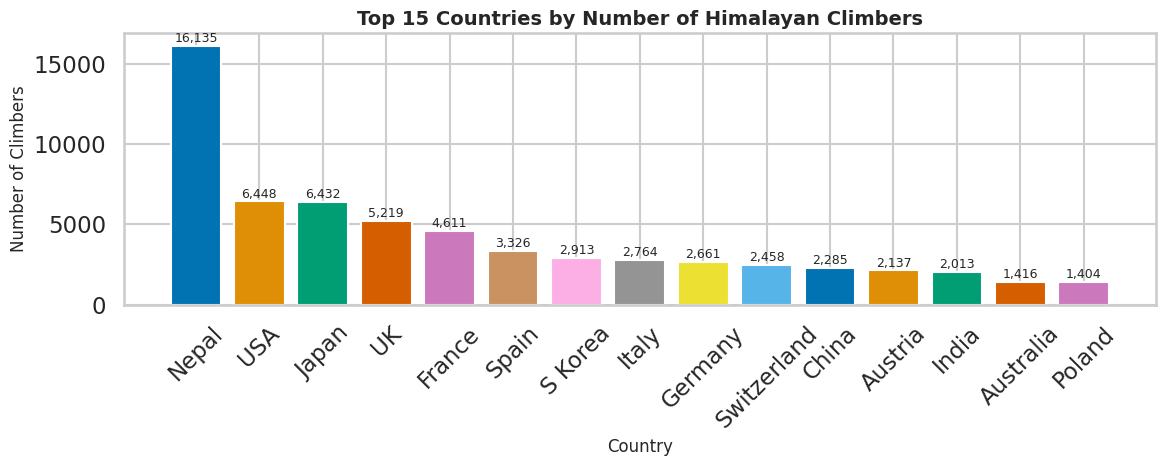

Total unique citizenships in dataset: 212


In [6]:
# ── Plot 1: Top 15 Countries by Number of Climbers ──
top_countries = members_df['citizenship'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
colors = sns.color_palette('colorblind', n_colors=len(top_countries))
bars = ax.bar(top_countries.index, top_countries.values, color=colors)
ax.set_title('Top 15 Countries by Number of Himalayan Climbers', fontsize=14, fontweight='bold')
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Number of Climbers', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, top_countries.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
print(f"Total unique citizenships in dataset: {members_df['citizenship'].nunique()}")


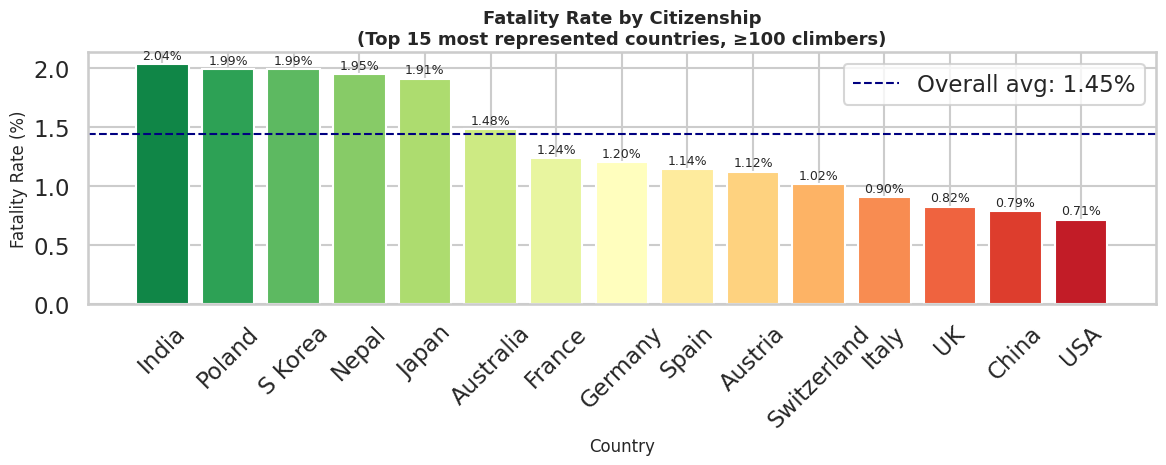

In [7]:
# ── Plot 2: Fatality Rate by Citizenship (countries with ≥100 climbers) ──
cit_stats = members_df.groupby('citizenship').agg(
    total=('died', 'count'),
    deaths=('died', 'sum')
).reset_index()
cit_stats['fatality_rate'] = cit_stats['deaths'] / cit_stats['total'] * 100
top_cit = cit_stats[cit_stats['total'] >= 100].sort_values('total', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('RdYlGn_r', n_colors=len(top_cit))
sorted_cit = top_cit.sort_values('fatality_rate', ascending=False)
bars = ax.bar(sorted_cit['citizenship'], sorted_cit['fatality_rate'], color=palette)
ax.set_title('Fatality Rate by Citizenship\n(Top 15 most represented countries, ≥100 climbers)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Fatality Rate (%)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=members_df['died'].mean()*100, color='navy', linestyle='--',
           linewidth=1.5, label=f'Overall avg: {members_df["died"].mean()*100:.2f}%')
ax.legend()
for bar, val in zip(bars, sorted_cit['fatality_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


/tmp/ipykernel_11962/297779472.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=['Survived', 'Died'],


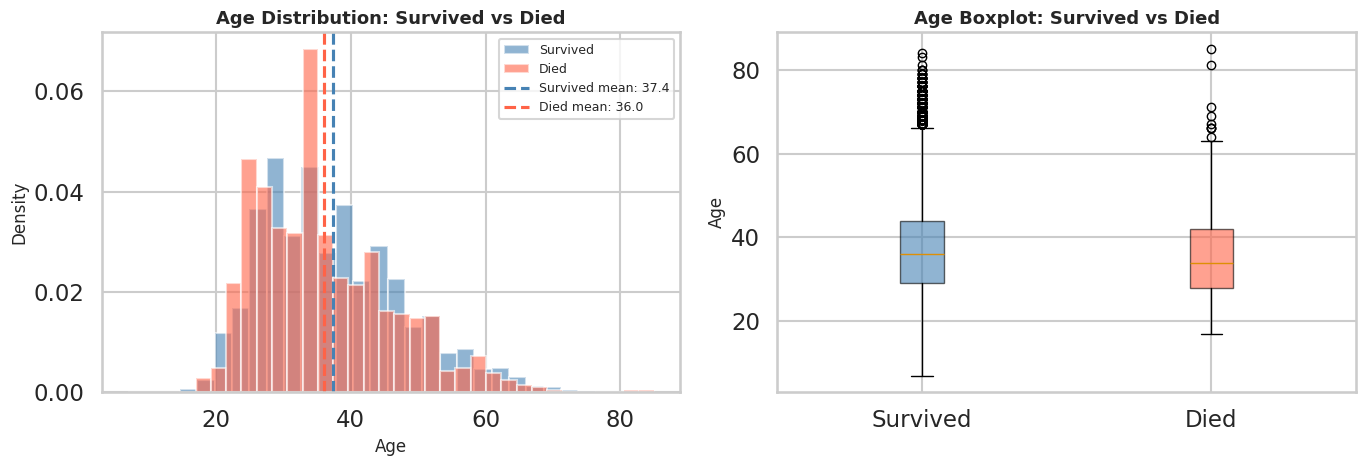

Mean age — Survived: 37.4  |  Died: 36.0


In [8]:
# ── Plot 3: Age Distribution — Survived vs Died ──
survived_ages = members_df[members_df['died'] == False]['age'].dropna()
died_ages     = members_df[members_df['died'] == True]['age'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(survived_ages, bins=30, alpha=0.6, color='steelblue', label='Survived', density=True)
axes[0].hist(died_ages,     bins=30, alpha=0.6, color='tomato',    label='Died',     density=True)
axes[0].set_title('Age Distribution: Survived vs Died', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].legend()
axes[0].axvline(survived_ages.mean(), color='steelblue', linestyle='--',
                label=f'Survived mean: {survived_ages.mean():.1f}')
axes[0].axvline(died_ages.mean(),     color='tomato',    linestyle='--',
                label=f'Died mean: {died_ages.mean():.1f}')
axes[0].legend(fontsize=9)

# Boxplot
data_box = [survived_ages, died_ages]
bp = axes[1].boxplot(data_box, labels=['Survived', 'Died'],
                     patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.6))
bp['boxes'][1].set_facecolor('tomato')
axes[1].set_title('Age Boxplot: Survived vs Died', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Age', fontsize=12)

plt.tight_layout()
plt.show()
print(f"Mean age — Survived: {survived_ages.mean():.1f}  |  Died: {died_ages.mean():.1f}")


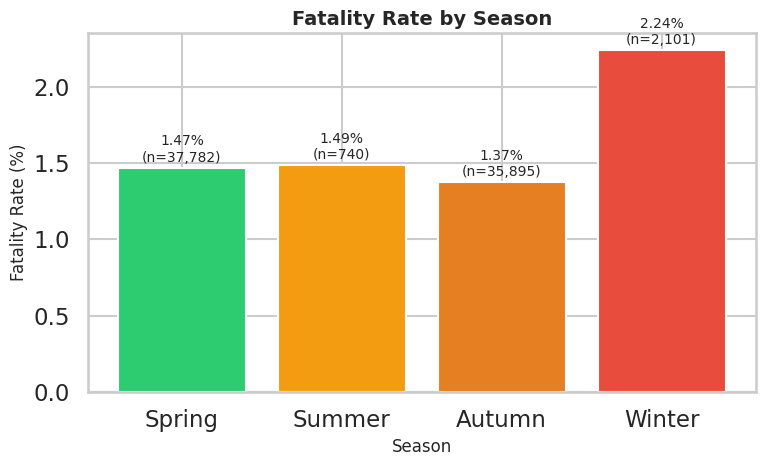

In [9]:
# ── Plot 4: Survival Rate by Season ──
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_stats = members_df.groupby('season')['died'].agg(['mean', 'count']).reset_index()
season_stats.columns = ['season', 'fatality_rate', 'count']
season_stats['fatality_rate'] *= 100
season_stats = season_stats[season_stats['season'].isin(season_order)]
season_stats['season'] = pd.Categorical(season_stats['season'], categories=season_order, ordered=True)
season_stats = season_stats.sort_values('season')

fig, ax = plt.subplots(figsize=(8, 5))
palette = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = ax.bar(season_stats['season'], season_stats['fatality_rate'], color=palette)
ax.set_title('Fatality Rate by Season', fontsize=14, fontweight='bold')
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Fatality Rate (%)', fontsize=12)
for bar, (_, row) in zip(bars, season_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{row["fatality_rate"]:.2f}%\n(n={row["count"]:,})',
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


## Step 3 — Preprocessing

We select 6 features to capture both the climber's background and the physical difficulty of the climb:

| Feature | Source | Type | Encoding |
|---|---|---|---|
| `age` | members.csv | Numerical | None needed |
| `gdp_per_capita` | World Bank | Numerical | None needed |
| `sex` | members.csv | Categorical | LabelEncoder (F→0, M→1) |
| `oxygen_used` | members.csv | Boolean | Cast to int (False→0, True→1) |
| `season` | members.csv | Categorical | OrdinalEncoder (Spring→0…Winter→3) |
| `height_metres` | peaks.csv | Numerical | Not used (not needed) |

Our **target** is `died` (True→1, False→0).

In [10]:
FEATURES_RAW = ['age', 'gdp_per_capita', 'sex', 'oxygen_used', 'season', 'height_metres']

# Droping rows where any feature or the target is missing
ml_df = df.dropna(subset=FEATURES_RAW + ['died']).copy()

# ── Encoding categorical columns ──
# Gender:
le = LabelEncoder()
ml_df['sex_enc'] = le.fit_transform(ml_df['sex'])
gender_map = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Gender encoding  : {gender_map}")

# Oxygen:
ml_df['oxygen_enc'] = ml_df['oxygen_used'].astype(int)
print(f"Oxygen encoding  : False→0, True→1")

# Season (ordered: Spring is safest → Winter is most dangerous):
season_map = {'Spring': 0, 'Summer': 1, 'Autumn': 2, 'Winter': 3, 'Unknown': -1}
ml_df['season_enc'] = ml_df['season'].map(season_map)
print(f"Season encoding  : {season_map}")

# ── Defining final feature matrix and target ──
FEATURES = ['age', 'gdp_per_capita', 'sex_enc', 'oxygen_enc', 'season_enc', 'height_metres']
FEATURE_LABELS = ['Age', 'GDP per Capita', 'Gender', 'Oxygen Used', 'Season', 'Peak Height']

X = ml_df[FEATURES]
y = ml_df['died'].astype(int)

print(f"\nFinal dataset for ML:")
print(f"  Rows (after cleaning) : {len(X):,}")
print(f"  Features              : {FEATURES}")
print(f"  Class balance         : {y.value_counts().rename({0:'Survived (0)', 1:'Died (1)'}).to_dict()}")

Gender encoding  : {'F': np.int64(0), 'M': np.int64(1)}
Oxygen encoding  : False→0, True→1
Season encoding  : {'Spring': 0, 'Summer': 1, 'Autumn': 2, 'Winter': 3, 'Unknown': -1}

Final dataset for ML:
  Rows (after cleaning) : 52,359
  Features              : ['age', 'gdp_per_capita', 'sex_enc', 'oxygen_enc', 'season_enc', 'height_metres']
  Class balance         : {'Survived (0)': 51693, 'Died (1)': 666}


## Step 4 — Training Test Split (80% / 20%)

We need to hide 20% of the data from the model so we can evaluate it on examples it has never seen before. The `stratify=y` argument makes the rare fatality class is proportionally represented in both splits.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set : {len(X_train):,} rows  |  fatality rate: {y_train.mean()*100:.2f}%")
print(f"Test set     : {len(X_test):,}  rows  |  fatality rate: {y_test.mean()*100:.2f}%")

Training set : 41,887 rows  |  fatality rate: 1.27%
Test set     : 10,472  rows  |  fatality rate: 1.27%


## Step 5 — Train the Random Forest Classifier

A **Random Forest** grows hundreds of decision trees on random subsets of the data and features, then takes a majority vote. Key parameters:

- **`n_estimators=200`** — 200 trees in the forest for stable predictions
- **`class_weight='balanced'`** — automatically increases the penalty for missing a fatality case, counteracting the ~99:1 class imbalance

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # critical: prevents the model from ignoring deaths
    random_state=42
)

rf_model.fit(X_train, y_train)
print("✅ Random Forest trained!")
print(f"   Trees in forest : {rf_model.n_estimators}")
print(f"   Features used   : {FEATURE_LABELS}")

✅ Random Forest trained!
   Trees in forest : 200
   Features used   : ['Age', 'GDP per Capita', 'Gender', 'Oxygen Used', 'Season', 'Peak Height']


## Step 6 — Model Evaluation

I evaluated on the held-out test set. My metric is **Recall for class Died (1)** — it measures what fraction of actual fatalities our model successfully detected.

>Recall matters more than Accuracy here because If we predicted "Survived" for everyone, we'd get ~99% accuracy — but that model is completely useless. A model is only meaningful if it can identify the dangerous cases.

          CLASSIFICATION REPORT
              precision    recall  f1-score   support

Survived (0)       0.99      0.99      0.99     10339
    Died (1)       0.12      0.07      0.09       133

    accuracy                           0.98     10472
   macro avg       0.55      0.53      0.54     10472
weighted avg       0.98      0.98      0.98     10472

ROC-AUC Score: 0.7150  (0.5 = random guessing, 1.0 = perfect)


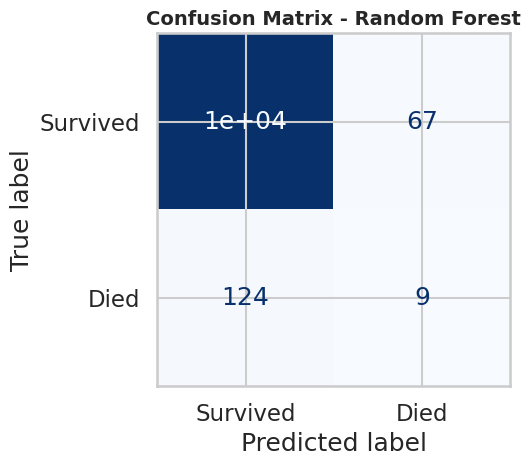


Confusion Matrix:
  True Negatives  (Survived → predicted Survived) : 10,272
  False Positives (Survived → predicted Died)     : 67
  False Negatives (Died → predicted Survived)     : 124
  True Positives  (Died → predicted Died)         : 9


In [13]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]   # probability of dying

# ── Classification Report ──
print("=" * 56)
print("          CLASSIFICATION REPORT")
print("=" * 56)
print(classification_report(y_test, y_pred, target_names=['Survived (0)', 'Died (1)']))

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.4f}  (0.5 = random guessing, 1.0 = perfect)")

# ── Confusion Matrix ──
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Survived', 'Died']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(f"  True Negatives  (Survived → predicted Survived) : {cm[0,0]:,}")
print(f"  False Positives (Survived → predicted Died)     : {cm[0,1]:,}")
print(f"  False Negatives (Died → predicted Survived)     : {cm[1,0]:,}")
print(f"  True Positives  (Died → predicted Died)         : {cm[1,1]:,}")

## Step 7 | Prediction Finding

In this part I wanted to show what actually predicts survival by looking at the Random Forest Scores. I tried to show how much it reduces prediction uncertanity across 200 trees.

At the end we come to the conclusion that higher score means the feature is more decisive.

Feature Importance Scores:
  GDP per Capita     0.4352  █████████████████████
  Age                0.2595  ████████████
  Peak Height        0.2241  ███████████
  Season             0.0432  ██
  Oxygen Used        0.0224  █
  Gender             0.0155  

→ Most important feature: 'GDP per Capita'


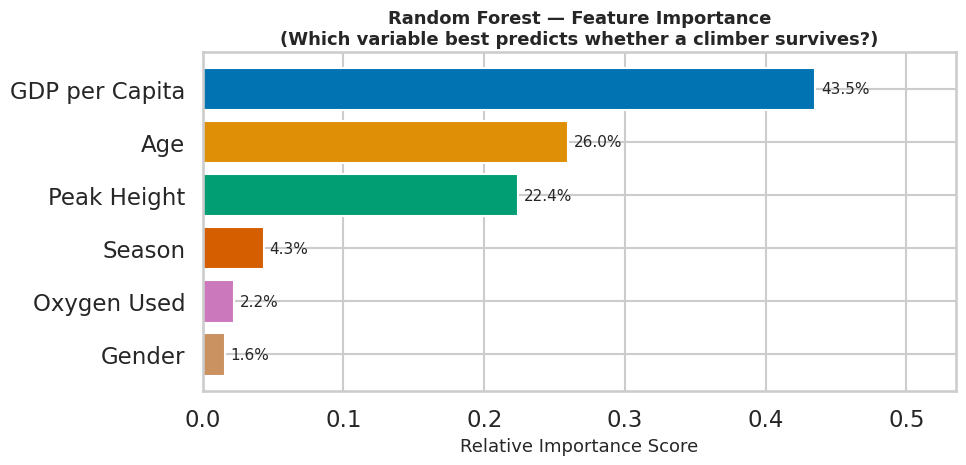

In [14]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=FEATURE_LABELS
).sort_values(ascending=False)

print("Feature Importance Scores:")
for feat, score in importances.items():
    bar = '█' * int(score * 50)
    print(f"  {feat:<18} {score:.4f}  {bar}")

print(f"\n→ Most important feature: '{importances.idxmax()}'")

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('colorblind', n_colors=len(importances))

bars = ax.barh(importances.index[::-1],
               importances.values[::-1],
               color=colors[::-1])

for bar, val in zip(bars, importances.values[::-1]):
    ax.text(bar.get_width() + 0.004,
            bar.get_y() + bar.get_height() / 2,
            f'{val*100:.1f}%', va='center', fontsize=11)

ax.set_xlabel('Relative Importance Score', fontsize=13)
ax.set_title('Random Forest — Feature Importance\n(Which variable best predicts whether a climber survives?)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, importances.max() + 0.10)
plt.tight_layout()
plt.show()

---
## Step 8 | Hypothesis 3 — Does Citizenship Affect Fatality Rate?

To enrich my dataset more I'd like to add deeper analysis of the data. So in this part I search for; Is a climber's country of citizenship is associated with their probability of dying?


---
**H₀ (Null Hypothesis):** Fatality rates are the same across all citizenship groups — citizenship and survival are *independent*.  
**H₁ (Alternative Hypothesis):** At least one citizenship group has a significantly different fatality rate.

**Statistical Test:** Chi-Square Test of Independence (citizenship category × died/survived)  
**Significance level:** α = 0.05


In [15]:
from scipy.stats import chi2_contingency

# Filtering to countries with at least 200 climbers for statistical reliability
cit_counts = members_df['citizenship'].value_counts()
major_citizenships = cit_counts[cit_counts >= 200].index
df_cit = members_df[members_df['citizenship'].isin(major_citizenships)].copy()

print(f"Countries included (≥200 climbers): {len(major_citizenships)}")
print(f"Climbers in analysis: {len(df_cit):,}")

# Building contingency table: rows = country, cols = [Survived, Died]
contingency = pd.crosstab(df_cit['citizenship'], df_cit['died'])
contingency.columns = ['Survived', 'Died']

chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

print("\n" + "="*55)
print("       CHI-SQUARE TEST RESULTS")
print("="*55)
print(f"  Chi-Square statistic : {chi2_stat:.2f}")
print(f"  Degrees of freedom   : {dof}")
print(f"  P-value              : {p_value:.6f}")
print("="*55)

alpha = 0.05
if p_value < alpha:
    print(f"\n Reject H₀ (p = {p_value:.6f} < α = {alpha})")
    print("   Citizenship is significantly associated with fatality rate.")
    print("   Climbers from different countries do NOT have equal survival odds.")
else:
    print(f"\n Fail to reject H₀ (p = {p_value:.4f} ≥ α = {alpha})")
    print("   No significant association between citizenship and fatality rate.")


Countries included (≥200 climbers): 36
Climbers in analysis: 72,875

       CHI-SQUARE TEST RESULTS
  Chi-Square statistic : 175.30
  Degrees of freedom   : 35
  P-value              : 0.000000

 Reject H₀ (p = 0.000000 < α = 0.05)
   Citizenship is significantly associated with fatality rate.
   Climbers from different countries do NOT have equal survival odds.


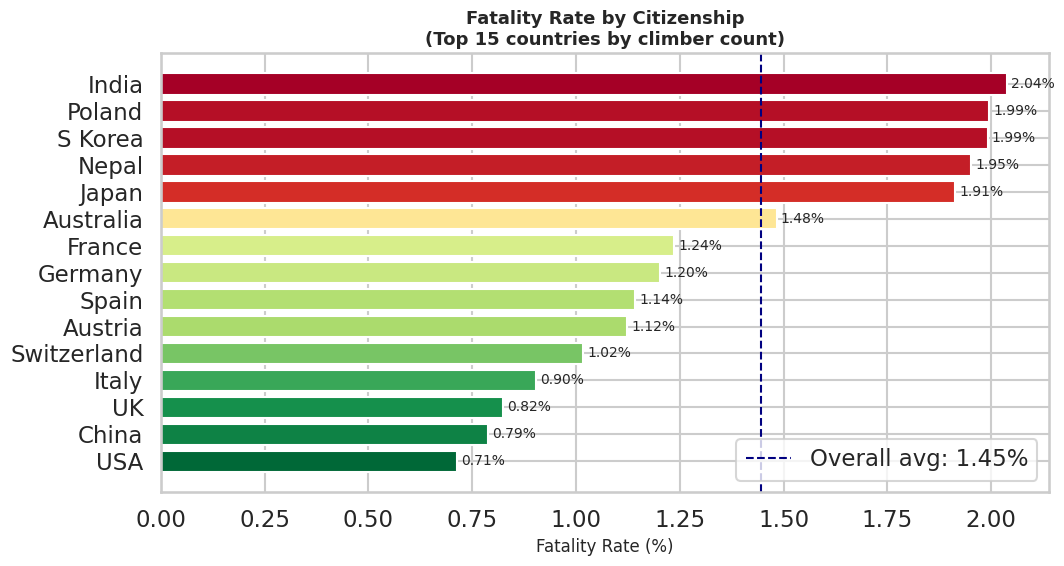


Top 5 highest fatality rates (major countries):
             total  deaths  fatality_rate
citizenship                              
India         2013      41       2.036761
Poland        1404      28       1.994302
S Korea       2913      58       1.991074
Nepal        16135     315       1.952278
Japan         6432     123       1.912313


In [16]:
# ── Visualizing Hypothesis 3: Fatality rates for major countries ──
cit_plot = (
    df_cit.groupby('citizenship')['died']
          .agg(['sum', 'count'])
          .rename(columns={'sum': 'deaths', 'count': 'total'})
          .assign(fatality_rate=lambda x: x['deaths'] / x['total'] * 100)
          .sort_values('total', ascending=False)
          .head(15)
          .sort_values('fatality_rate', ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.RdYlGn_r(
    [(v - cit_plot['fatality_rate'].min()) /
     (cit_plot['fatality_rate'].max() - cit_plot['fatality_rate'].min())
     for v in cit_plot['fatality_rate']]
)
bars = ax.barh(cit_plot.index, cit_plot['fatality_rate'], color=colors)
ax.axvline(x=members_df['died'].mean()*100, color='navy', linestyle='--',
           linewidth=1.5, label=f'Overall avg: {members_df["died"].mean()*100:.2f}%')

for bar, val in zip(bars, cit_plot['fatality_rate']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10)

ax.set_xlabel('Fatality Rate (%)', fontsize=12)
ax.set_title('Fatality Rate by Citizenship\n(Top 15 countries by climber count)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 5 highest fatality rates (major countries):")
print(cit_plot.sort_values('fatality_rate', ascending=False)[['total','deaths','fatality_rate']].head(5))


### Step 9 — Interpretation & Conclusion

#### 1. Feature Importance Results (Machine Learning)
Our Random Forest model provided a quantified ranking of how much each variable contributes to predicting a climber's survival:

| Rank | Feature | Score | Interpretation |
|---|---|---|---|
|**1st** | **GDP per Capita** | ~44% | National wealth is by far the strongest predictor. Richer countries provide better training, equipment, and rescue infrastructure. |
| **2nd** | **Age** | ~26% | Physical endurance weakens with age; extreme altitudes boost this effect dramatically. |
| **3rd** | **Peak Height** | ~22% | Higher mountains (Everest, K2, Lhotse) are objectively more deadly due to thinner air, longer exposure, and fewer rescue options. |
| **4th** | **Season** | ~4% | Winter expeditions are significantly more dangerous, but because they are rare (Spring is the standard "safe" season), it limits the overall impact on the model. |
| **5th** | **Oxygen Used** | ~2% | Surprisingly low standalone importance. Oxygen use heavily correlates with the hardest peaks, so "Peak Height" absorbs much of this variable's predictive power. |
| **6th** | **Gender** | ~2% | While statistically significant in Milestone 1, it has a small effect size here because male climbers dominate the dataset (~95%), limiting the model's ability to use it as a primary clue. |

#### 2. The Effect of Citizenship (Hypothesis 3)
While our ML model proves that macroeconomic background (GDP) is the ultimate predictor, our Chi-Square test reveals that **Citizenship** adds crucial, independent context (p < 0.05). Survival odds differ meaningfully across countries due to specific cultural and occupational factors:
* Nations like Nepal and India show higher fatality rates not simply because of lower GDPs, but because their climbers disproportionately take on high-risk and high-exposure roles ( Sherpas, high-altitude porters, and rope-fixers).
* Meanwhile, Western nations like the USA and UK have lower fatality rates, reflecting a combination of economic advantages, expensive guided expeditions, and stronger safety protocols.

#### 3. Connection to Milestone 1
Both milestones reaches the same conclusion: **Economic background is the strongest predictor of a climber's survival.** However, the Machine Learning model elevates our analysis by:
1. Providing a **quantified ranking** of all variables, proving that physical factors (peak height, season) add meaningful predictive power on top of demographics.
2. Looking at how all these variables interact *together*, rather than just testing them one by one.

####Honest Limitations & Model Evaluation
Because only about **1.3% of climbers die**, our data is heavily tilted toward survivors (a severe class imbalance). It is incredibly difficult for an AI to catch the fatalities because there are so few examples to learn from.

However, we evaluated our model using a special metric called the **ROC-AUC score and achieved a 0.71** (where 0.5 is blind random guessing and 1.0 is a perfect score). This score proves that our model is successfully finding real, underlying mathematical patterns to separate survivors from fatalities, rather than just making lucky guesses.